In [12]:
import pybamm
import matplotlib.pyplot as plt

In [2]:
# Create and solve model
model = pybamm.lithium_ion.SPM()

# create simulation
sim = pybamm.Simulation(model)

# solve for 1 hour
sim.solve([0, 3600])

# plot
#sim.plot()

print(sim.solution.all_models[0].variables.keys())

dict_keys(['Time [s]', 'Time [min]', 'Time [h]', 'x [m]', 'x_n [m]', 'x_s [m]', 'x_p [m]', 'r_n [m]', 'r_p [m]', 'Current variable [A]', 'Total current density [A.m-2]', 'Current [A]', 'C-rate', 'Discharge capacity [A.h]', 'Throughput capacity [A.h]', 'Discharge energy [W.h]', 'Throughput energy [W.h]', 'Porosity', 'Negative electrode porosity', 'X-averaged negative electrode porosity', 'Separator porosity', 'X-averaged separator porosity', 'Positive electrode porosity', 'X-averaged positive electrode porosity', 'Porosity change', 'Negative electrode porosity change [s-1]', 'X-averaged negative electrode porosity change [s-1]', 'Separator porosity change [s-1]', 'X-averaged separator porosity change [s-1]', 'Positive electrode porosity change [s-1]', 'X-averaged positive electrode porosity change [s-1]', 'Negative electrode interface utilisation variable', 'X-averaged negative electrode interface utilisation variable', 'Negative electrode interface utilisation', 'X-averaged negative el

In [10]:
#extract total capacity discharged
Q= sim.solution['Discharge capacity [A.h]'].entries
Q_total = Q[-1]
SoC=1 - (Q/Q_total)

#extract voltage at end of discharge
V = sim.solution['Terminal voltage [V]'].entries

#extract time
t = sim.solution['Time [s]'].entries

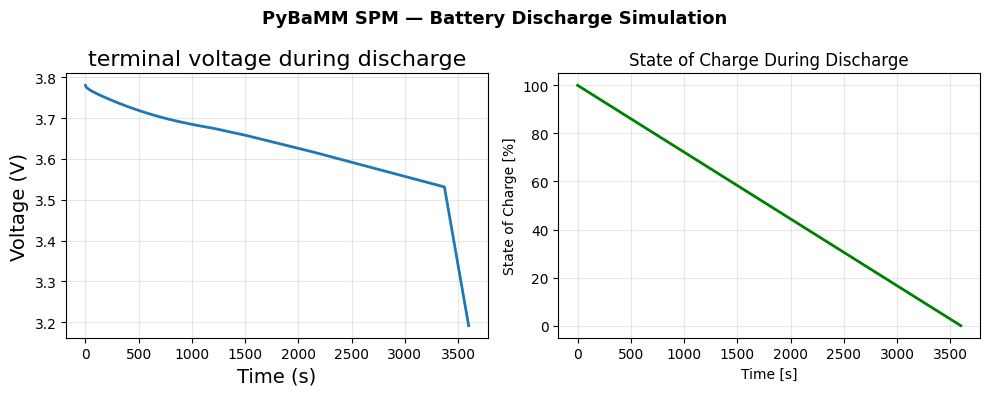

In [15]:
#plot soc and voltage

fig,axes= plt.subplots(1,2,figsize=(10,4))

axes[0].plot(t,V,linewidth=2)
axes[0].set_xlabel('Time (s)',fontsize=14)
axes[0].set_ylabel('Voltage (V)',fontsize=14)
axes[0].set_title('terminal voltage during discharge',fontsize=16)
axes[0].grid(True, alpha=0.3)

# SoC vs time
axes[1].plot(t, SoC * 100, color='green', linewidth=2)
axes[1].set_xlabel('Time [s]')
axes[1].set_ylabel('State of Charge [%]')
axes[1].set_title('State of Charge During Discharge')
axes[1].grid(True, alpha=0.3)

plt.suptitle('PyBaMM SPM — Battery Discharge Simulation',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('../results/spm_voltage_soc.png', dpi=150)
plt.show()

Sharp drop indicates battery depletion — critical threshold for BMS  
Gradual decline with sharp drop at end of discharge  
Voltage and SoC are correlated but not linear  